# Smart Farming Fog DNN

**A self-contained research notebook for soil matric potential prediction and fog-enabled irrigation support.**

This notebook documents and modernizes experiments associated with:

> **Matheus Cordeiro**, Catherine Markert, Sayonara S. Araújo, Nídia G. S. Campos,  
> Rubens S. Gondim, Ticiana L. Coelho da Silva, and Atslands R. da Rocha.  
> *Towards Smart Farming: Fog-enabled intelligent irrigation system using deep neural networks.*  
> **Future Generation Computer Systems**, 129, 115–124, 2022.  
> DOI: [10.1016/j.future.2021.11.013](https://doi.org/10.1016/j.future.2021.11.013)

This repository is maintained by [Matheus Cordeiro](https://github.com/fobos123deimos), the first author listed in the associated publication.

The notebook is intentionally self-contained: preprocessing, mathematical models, neural architectures, evaluation, and deployment logic are defined directly in its cells.


<p align="center">
  <a href="https://colab.research.google.com/github/fobos123deimos/smart-farming-fog-dnn/blob/main/smart_farming_fog_dnn.ipynb">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab">
  </a>
</p>

> The original datasets are not redistributed in this repository. Place
> `caju_data_new.csv` beside the notebook or upload it to the Colab session
> before running the data-loading section.


## 1. Scientific Workflow

The proposed workflow has four phases:

1. **Data sources:** weather, irrigation, crop coefficient, and soil matric potential.
2. **Data preprocessing:** domain filtering, MinMax scaling, KNN imputation, and K-fold splitting.
3. **Data modeling:** dense regression, LSTM, and BiLSTM.
4. **Data prediction:** model selection and fog-oriented deployment.

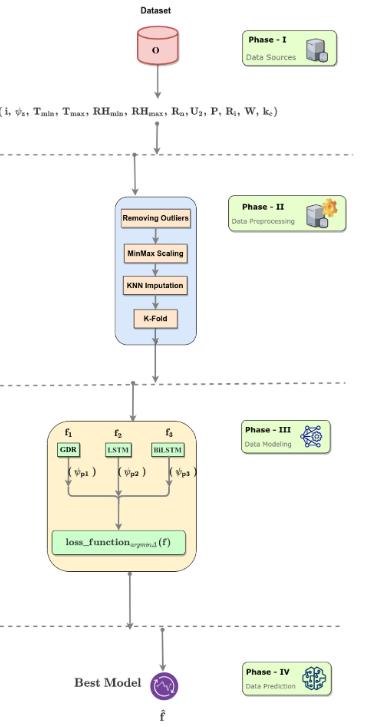

*Four-phase framework used to create deep-learning models for soil matric potential prediction.*


## 2. Main Contributions of the Article

The study contributes a complete smart-irrigation pipeline rather than only a prediction model:

- soil matric potential prediction at multiple depths;
- comparison of dense regression, LSTM, and BiLSTM structures;
- KNN imputation for missing sensor observations;
- use of predicted soil information in irrigation management;
- conversion of trained models to TensorFlow Lite;
- evaluation on a Raspberry Pi fog node.

The published experiments used real cashew and coconut field data and assessed both predictive performance and embedded-device viability.


## 3. Published Benchmark Results

### Coconut dataset — MAE in kPa

| Model | 15 cm | 45 cm | 75 cm |
|---|---:|---:|---:|
| GDR test 1 | 7.1 | 6.0 | 6.5 |
| GDR test 2 | 7.7 | 7.0 | 7.3 |
| GDR test 3 | 6.5 | 5.5 | 6.0 |
| LSTM | 6.3 | 5.4 | 5.7 |
| BiLSTM | 6.2 | 5.4 | 5.9 |

### Cashew dataset — MAE in kPa

| Model | 15 cm | 45 cm | 75 cm |
|---|---:|---:|---:|
| GDR 1 | 25.41 | 22.60 | 18.98 |
| GDR 2 | 21.08 | 22.22 | 17.29 |
| LSTM | 23.52 | 18.89 | 16.89 |
| BiLSTM | 22.91 | 21.60 | 17.14 |

These tables are reference values from the publication. The executable sections below provide a modernized workflow and should not be presented as an exact numerical reproduction without the original data and environment.


# Part I — Environment and Configuration

This section imports the scientific Python stack and defines one centralized experiment configuration. Keeping random seeds and hyperparameters in one object makes the workflow easier to inspect and reproduce.


In [ ]:
from __future__ import annotations

import pickle
import random
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

## Experiment configuration

The configuration controls:

- random initialization;
- number of cross-validation folds;
- number of neighbors used by KNN imputation;
- training epochs and batch size;
- learning rate;
- training verbosity.

The notebook also creates an `outputs/` directory for generated models, tables, and figures.


In [ ]:
@dataclass(frozen=True)
class ExperimentConfig:
    random_state: int = 42
    n_splits: int = 20
    n_neighbors: int = 5
    epochs: int = 100
    batch_size: int = 10
    learning_rate: float = 1e-3
    verbose: int = 0


def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

In [ ]:
CONFIG = ExperimentConfig(
    random_state=42,
    n_splits=20,
    n_neighbors=5,
    epochs=100,
    batch_size=10,
    learning_rate=1e-3,
    verbose=0,
)

set_global_seed(CONFIG.random_state)

DATA_PATH = Path("caju_data_new.csv")
OUTPUT_DIR = Path("outputs")
FIGURES_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CONFIG

# Part II — Data Formulation, Loading, and Domain Cleaning

## Prediction problem

A daily observation combines location, weather, crop, irrigation, and soil information:

$$
\mathbf{x}_i =
\left[
i,\,
T_{\min},\,
T_{\max},\,
RH_{\min},\,
RH_{\max},\,
R_n,\,
U_2,\,
P,\,
R_i,\,
W,\,
k_c
\right].
$$

The target is the soil matric potential at depth $z$:

$$
y(\mathbf{x}_i)=\psi_z.
$$

The learning problem seeks a predictive function $\hat{f}$ that minimizes a loss over the observations:

$$
\hat{f}
=
\operatorname*{arg\,min}_{f\in\mathcal{H}}
\Delta(f).
$$

## Feature dictionary

| Field | Meaning | Unit |
|---|---|---|
| `Data` | Observation date | date |
| `T1-15`, `T1-45`, `T1-75` | Tensiometer reading at monitoring point 1 | kPa |
| `W1` | Irrigation water applied at monitoring point 1 | L |
| `Kc` | Crop coefficient | dimensionless |
| `T_max`, `T_min` | Maximum and minimum air temperature | °C |
| `RH_max`, `RH_min` | Maximum and minimum relative humidity | % |
| `Rn` | Net solar radiation | $\mathrm{MJ\,m^{-2}\,d^{-1}}$ |
| `U2` | Wind speed | $\mathrm{m\,s^{-1}}$ |
| `P` | Atmospheric pressure | kPa |
| `Ri_f` | Rainfall measured at the experimental field | mm |

The next code cell defines the loading, monitoring-spot selection, and domain-cleaning functions used by this section.


In [ ]:
def load_dataset(path: str | Path) -> pd.DataFrame:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"Dataset not found at '{path}'. Place caju_data_new.csv beside "
            "the notebook or upload it to the Colab session."
        )

    data = pd.read_csv(path)
    if "Data" in data.columns:
        data["Data"] = pd.to_datetime(
            data["Data"],
            dayfirst=True,
            errors="coerce",
        )
    return data


def select_monitoring_spot(data: pd.DataFrame, spot: int = 1) -> pd.DataFrame:
    if spot != 1:
        raise NotImplementedError(
            "This notebook documents monitoring spot T1. Extend this function "
            "before selecting another monitoring spot."
        )

    columns_to_drop = [
        *[f"T{i}-{depth}" for i in range(2, 10) for depth in (15, 45, 75)],
        *[f"W{i}" for i in range(2, 10)],
    ]
    available = [column for column in columns_to_drop if column in data.columns]
    return data.drop(columns=available).copy()


def _monthly_three_sigma_mask(
    data: pd.DataFrame,
    column: str,
) -> pd.Series:
    if "Data" not in data.columns or column not in data.columns:
        return pd.Series(True, index=data.index)

    month = data["Data"].dt.month
    grouped = data.groupby(month)[column]
    mean = grouped.transform("mean")
    std = grouped.transform("std").fillna(0.0)
    safe_std = (3.0 * std).replace(0.0, np.inf)
    return (data[column] - mean).abs() < safe_std


def remove_domain_outliers(data: pd.DataFrame) -> pd.DataFrame:
    clean = data.copy()

    for column in ("T_max", "T_min"):
        if column in clean.columns:
            clean = clean[clean[column].between(18, 50, inclusive="both")]

    if "P" in clean.columns:
        clean = clean[clean["P"] <= 100]

    if "Ri_f" in clean.columns:
        clean = clean[clean["Ri_f"] <= 200]

    depth_columns = [
        column
        for column in ("T1-15", "T1-45", "T1-75")
        if column in clean.columns
    ]
    if len(depth_columns) == 3 and "Data" in clean.columns:
        simultaneous_zero = clean[depth_columns].eq(0).all(axis=1)
        outside_april = clean["Data"].dt.month.ne(4)
        clean = clean[~(simultaneous_zero & outside_april)]

    for column in ("Rn", "U2"):
        clean = clean[_monthly_three_sigma_mask(clean, column)]

    return clean.reset_index(drop=True)

## Load the dataset

The notebook focuses on monitoring point `T1`. Other monitoring-point columns are removed so that the experiment uses a clear set of targets at 15, 45, and 75 cm.


In [ ]:
data_raw = load_dataset(DATA_PATH)
data_t1 = select_monitoring_spot(data_raw, spot=1)

print(f"Raw shape: {data_raw.shape}")
print(f"T1 shape:  {data_t1.shape}")
display(data_t1.head())

## Domain-based outlier rules

The publication reports the following filters:

1. remove simultaneous zero readings at 15, 45, and 75 cm outside April;
2. retain temperatures between 18 °C and 50 °C;
3. remove pressure values above 100 kPa;
4. remove field rainfall values above 200 mm;
5. remove monthly net-radiation and wind-speed observations at least three standard deviations from the monthly mean.

These are domain rules rather than universal statistical assumptions. They should be reviewed before applying the notebook to a different crop, soil, or climate.


In [ ]:
data_clean = remove_domain_outliers(data_t1)

summary = pd.DataFrame(
    {
        "stage": ["raw T1 data", "after domain cleaning"],
        "rows": [len(data_t1), len(data_clean)],
        "columns": [data_t1.shape[1], data_clean.shape[1]],
    }
)
display(summary)

## Missing-data inspection

Before modeling, the notebook measures the percentage of missing values in each column. Missing target values and missing predictor values should be interpreted differently: KNN imputation is applied to predictors inside each training fold, while the prediction target must be available for supervised evaluation.


In [ ]:
missing = (
    data_clean.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_percent")
    .to_frame()
)

display(missing)

ax = missing[missing["missing_percent"] > 0].plot(
    kind="bar",
    figsize=(11, 4),
    legend=False,
    title="Missing values after domain cleaning",
)
ax.set_ylabel("Missing values (%)")
ax.set_xlabel("Feature")
plt.tight_layout()
plt.show()

## Feature and target selection

The three matric-potential depths are modeled as independent targets. Weather, crop coefficient, rainfall, atmospheric pressure, and irrigation variables form the predictor set.


In [ ]:
TARGET_COLUMNS = ["T1-15", "T1-45", "T1-75"]
FEATURE_COLUMNS = [
    "W1",
    "Kc",
    "T_max",
    "T_min",
    "RH_min",
    "RH_max",
    "Rn",
    "U2",
    "P",
    "Ri_f",
]

required = FEATURE_COLUMNS + TARGET_COLUMNS
missing_columns = sorted(set(required) - set(data_clean.columns))
if missing_columns:
    raise KeyError(f"Dataset is missing required columns: {missing_columns}")

display(data_clean[required].describe().T)

## Exploratory target distributions

The following histograms help reveal differences in scale, variability, and concentration among the three monitored depths.


In [ ]:
axes = data_clean[TARGET_COLUMNS].plot(
    kind="hist",
    bins=30,
    alpha=0.55,
    figsize=(11, 5),
    title="Distribution of soil matric potential by depth",
)
axes.set_xlabel("Matric potential (kPa)")
plt.tight_layout()
plt.show()

# Part III — Van Genuchten Water-Retention Model

The Van Genuchten model maps matric potential $\psi$ to volumetric water content $\theta$:

$$
\theta(\psi)
=
\theta_r
+
\frac{\theta_s-\theta_r}
{
\left[
1+\left(\alpha|\psi|\right)^n
\right]^{1-\frac{1}{n}}
}.
$$

The parameters used in the original exploratory notebook were:

| Depth | $\theta_r$ | $\theta_s$ | $\alpha$ | $n$ |
|---:|---:|---:|---:|---:|
| 15 cm | 0.052088333 | 0.38856 | 0.34201 | 3.026733333 |
| 45 cm | 0.054059 | 0.406413 | 0.41654 | 3.386433 |
| 75 cm | 0.52884 | 0.65222 | 0.13584 | 1.6947 |

These parameters describe a specific soil characterization and must be validated before reuse in another field.


In [ ]:
def van_genuchten(
    matric_potential,
    theta_r: float,
    theta_s: float,
    alpha: float,
    n: float,
):
    psi = np.asarray(matric_potential, dtype=float)
    m = 1.0 - (1.0 / n)
    return theta_r + (theta_s - theta_r) / (
        1.0 + (alpha * np.abs(psi)) ** n
    ) ** m

In [ ]:
VAN_GENUCHTEN_PARAMETERS = {
    15: {"theta_r": 0.052088333, "theta_s": 0.38856, "alpha": 0.34201, "n": 3.026733333},
    45: {"theta_r": 0.054059, "theta_s": 0.406413, "alpha": 0.41654, "n": 3.386433},
    75: {"theta_r": 0.52884, "theta_s": 0.65222, "alpha": 0.13584, "n": 1.6947},
}

psi = np.linspace(0, 100, 500)

fig, ax = plt.subplots(figsize=(10, 5))
for depth, params in VAN_GENUCHTEN_PARAMETERS.items():
    theta = van_genuchten(psi, **params)
    ax.plot(psi, theta, label=f"{depth} cm")

ax.set_title("Van Genuchten water-retention curves")
ax.set_xlabel(r"$|\psi|$ (kPa)")
ax.set_ylabel(r"$\theta$ (cm³/cm³)")
ax.legend(title="Depth")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Part IV — Neural Architectures

## Dense regression

The dense baseline uses fully connected layers and a Gaussian activation:

$$
\phi(x)=e^{-x^2}.
$$

## Long Short-Term Memory

For input $\mathbf{x}_t$, previous hidden state $\mathbf{h}_{t-1}$, and previous cell state $\mathbf{c}_{t-1}$:

$$
\mathbf{i}_t
=
\sigma\left(
W_i\mathbf{x}_t
+
U_i\mathbf{h}_{t-1}
+
\mathbf{b}_i
\right).
$$

$$
\mathbf{f}_t
=
\sigma\left(
W_f\mathbf{x}_t
+
U_f\mathbf{h}_{t-1}
+
\mathbf{b}_f
\right).
$$

$$
\mathbf{o}_t
=
\sigma\left(
W_o\mathbf{x}_t
+
U_o\mathbf{h}_{t-1}
+
\mathbf{b}_o
\right).
$$

$$
\tilde{\mathbf{c}}_t
=
\tanh\left(
W_c\mathbf{x}_t
+
U_c\mathbf{h}_{t-1}
+
\mathbf{b}_c
\right).
$$

$$
\mathbf{c}_t
=
\mathbf{f}_t\odot\mathbf{c}_{t-1}
+
\mathbf{i}_t\odot\tilde{\mathbf{c}}_t.
$$

$$
\mathbf{h}_t
=
\mathbf{o}_t\odot\tanh(\mathbf{c}_t).
$$

## Bidirectional LSTM

A BiLSTM combines forward and backward recurrent representations:

$$
\mathbf{h}_t^{\mathrm{bi}}
=
\left[
\overrightarrow{\mathbf{h}}_t;
\overleftarrow{\mathbf{h}}_t
\right].
$$

The following cell implements the dense, LSTM, and BiLSTM builders used later in cross-validation.


In [ ]:
def gaussian_activation(x):
    return tf.exp(-tf.square(x))


def build_dense_regressor(
    n_features: int,
    learning_rate: float = 1e-3,
) -> tf.keras.Model:
    inputs = tf.keras.Input(shape=(n_features,), name="features")
    x = tf.keras.layers.Dense(
        16,
        activation=gaussian_activation,
    )(inputs)
    x = tf.keras.layers.Dense(
        16,
        activation=gaussian_activation,
    )(x)
    outputs = tf.keras.layers.Dense(
        1,
        activation="linear",
        name="matric_potential",
    )(x)

    model = tf.keras.Model(inputs, outputs, name="dense_regressor")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate,
        ),
        loss="mae",
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model


def build_lstm_regressor(
    n_features: int,
    learning_rate: float = 1e-3,
) -> tf.keras.Model:
    inputs = tf.keras.Input(
        shape=(n_features, 1),
        name="feature_sequence",
    )
    x = tf.keras.layers.LSTM(16, activation="tanh")(inputs)
    x = tf.keras.layers.Dense(16, activation="tanh")(x)
    outputs = tf.keras.layers.Dense(
        1,
        activation="linear",
        name="matric_potential",
    )(x)

    model = tf.keras.Model(inputs, outputs, name="lstm_regressor")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate,
        ),
        loss="mae",
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model


def build_bilstm_regressor(
    n_features: int,
    learning_rate: float = 1e-3,
) -> tf.keras.Model:
    inputs = tf.keras.Input(
        shape=(n_features, 1),
        name="feature_sequence",
    )
    x = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(16, activation="tanh")
    )(inputs)
    x = tf.keras.layers.Dense(16, activation="tanh")(x)
    outputs = tf.keras.layers.Dense(
        1,
        activation="linear",
        name="matric_potential",
    )(x)

    model = tf.keras.Model(inputs, outputs, name="bilstm_regressor")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate,
        ),
        loss="mae",
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model


MODEL_BUILDERS: dict[str, Callable[..., tf.keras.Model]] = {
    "dense": build_dense_regressor,
    "lstm": build_lstm_regressor,
    "bilstm": build_bilstm_regressor,
}


def reshape_for_model(x: np.ndarray, model_name: str) -> np.ndarray:
    if model_name in {"lstm", "bilstm"}:
        return x[..., None]
    return x

# Part V — Leakage-Resistant Preprocessing and Cross-Validation

## MinMax scaling

For a feature $X$, the scaler must learn its minimum and maximum from the training fold only:

$$
X_{\text{scaled}}
=
\frac{
X_{\text{original}}-\min(X_{\text{train}})
}{
\max(X_{\text{train}})-\min(X_{\text{train}})
}.
$$

The inverse target transformation is:

$$
Y_{\text{original}}
=
Y_{\text{scaled}}
\left[
\max(Y_{\text{train}})-\min(Y_{\text{train}})
\right]
+
\min(Y_{\text{train}}).
$$

## KNN imputation

For observations $i$ and $j$, a range-normalized Euclidean distance can be represented as:

$$
d(i,j)
=
\sqrt{
\sum_{k\in\mathcal{A}_{ij}}
\left(
\frac{x_{ik}-x_{jk}}
{\max(X_k)-\min(X_k)}
\right)^2
}.
$$

Here, $\mathcal{A}_{ij}$ contains the attributes observed for both samples.

## Mean Absolute Error

Predictions are inverse-transformed before evaluation:

$$
\operatorname{MAE}
=
\frac{1}{m}
\sum_{j=1}^{m}
\left|
y_j-\hat{y}_j
\right|.
$$

The final error is therefore reported in kPa.

## Fold procedure

Each fold follows this order:

1. split training and test indices;
2. fit KNN imputation on the training partition;
3. transform the test partition with the training imputer;
4. fit feature and target scalers on training data;
5. create a fresh neural model;
6. train with an internal validation split;
7. inverse-transform predictions;
8. calculate MAE in kPa.

The next cell implements this complete procedure.


In [ ]:
def cross_validate_depth(
    data: pd.DataFrame,
    feature_columns: list[str],
    target_column: str,
    model_name: str,
    config: ExperimentConfig,
) -> tuple[pd.DataFrame, list[tf.keras.Model]]:
    if model_name not in MODEL_BUILDERS:
        raise ValueError(
            f"Unknown model '{model_name}'. "
            f"Choose one of {list(MODEL_BUILDERS)}."
        )

    x_raw = data[feature_columns].to_numpy(dtype=float)
    y_raw = data[[target_column]].to_numpy(dtype=float)

    splitter = KFold(
        n_splits=config.n_splits,
        shuffle=True,
        random_state=config.random_state,
    )

    rows = []
    models = []

    for fold, (train_index, test_index) in enumerate(
        splitter.split(x_raw),
        start=1,
    ):
        set_global_seed(config.random_state + fold)

        x_train_raw = x_raw[train_index]
        x_test_raw = x_raw[test_index]
        y_train_raw = y_raw[train_index]
        y_test_raw = y_raw[test_index]

        # Fit every preprocessing object only on the training fold.
        imputer = KNNImputer(
            n_neighbors=config.n_neighbors,
            weights="distance",
        )
        x_train = imputer.fit_transform(x_train_raw)
        x_test = imputer.transform(x_test_raw)

        x_scaler = MinMaxScaler()
        x_train = x_scaler.fit_transform(x_train)
        x_test = x_scaler.transform(x_test)

        y_scaler = MinMaxScaler()
        y_train = y_scaler.fit_transform(y_train_raw)

        x_train_model = reshape_for_model(x_train, model_name)
        x_test_model = reshape_for_model(x_test, model_name)

        model = MODEL_BUILDERS[model_name](
            n_features=x_train.shape[1],
            learning_rate=config.learning_rate,
        )

        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=15,
                restore_best_weights=True,
            )
        ]

        model.fit(
            x_train_model,
            y_train,
            validation_split=0.15,
            epochs=config.epochs,
            batch_size=config.batch_size,
            verbose=config.verbose,
            callbacks=callbacks,
        )

        y_pred_scaled = model.predict(x_test_model, verbose=0)
        y_pred = y_scaler.inverse_transform(y_pred_scaled)
        mae = mean_absolute_error(y_test_raw, y_pred)

        rows.append(
            {
                "fold": fold,
                "depth": target_column,
                "model": model_name,
                "mae_kpa": float(mae),
                "n_train": len(train_index),
                "n_test": len(test_index),
            }
        )
        models.append(model)

    return pd.DataFrame(rows), models

## Focused cross-validation run

Select one architecture and evaluate it independently for the 15, 45, and 75 cm targets. With 20 folds and three depths, this cell trains 60 models.


In [ ]:
# Select one architecture for a focused run.
# Valid values: "dense", "lstm", "bilstm"
MODEL_NAME = "bilstm"

fold_results = []
trained_models = {}

for target in TARGET_COLUMNS:
    result, models = cross_validate_depth(
        data=data_clean,
        feature_columns=FEATURE_COLUMNS,
        target_column=target,
        model_name=MODEL_NAME,
        config=CONFIG,
    )
    fold_results.append(result)
    trained_models[target] = models

results = pd.concat(fold_results, ignore_index=True)
display(results.head())

## Cross-validation summary

The mean describes average predictive error, while the standard deviation reflects stability across folds. Both should be considered when comparing architectures.


In [ ]:
summary_results = (
    results.groupby(["model", "depth"])["mae_kpa"]
    .agg(["mean", "std", "min", "max", "count"])
    .reset_index()
)

display(summary_results)
summary_results.to_csv(
    OUTPUT_DIR / f"{MODEL_NAME}_cross_validation_summary.csv",
    index=False,
)

In [ ]:
pivot = results.pivot(index="fold", columns="depth", values="mae_kpa")

ax = pivot.plot(
    kind="box",
    figsize=(10, 5),
    title=f"{MODEL_NAME.upper()} — MAE distribution across folds",
)
ax.set_ylabel("MAE (kPa)")
ax.set_xlabel("Soil depth target")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / f"{MODEL_NAME}_mae_by_depth.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

## Optional full benchmark

The next cell compares all three architectures. It is disabled by default because it trains one model for every combination of architecture, depth, and fold.


In [ ]:
RUN_FULL_BENCHMARK = False

if RUN_FULL_BENCHMARK:
    all_results = []

    for model_name in ("dense", "lstm", "bilstm"):
        for target in TARGET_COLUMNS:
            result, _ = cross_validate_depth(
                data=data_clean,
                feature_columns=FEATURE_COLUMNS,
                target_column=target,
                model_name=model_name,
                config=CONFIG,
            )
            all_results.append(result)

    benchmark_results = pd.concat(all_results, ignore_index=True)
    benchmark_summary = (
        benchmark_results.groupby(["model", "depth"])["mae_kpa"]
        .agg(["mean", "std"])
        .reset_index()
    )
    display(benchmark_summary)
    benchmark_results.to_csv(
        OUTPUT_DIR / "full_benchmark_folds.csv",
        index=False,
    )

# Part VI — Final Model Training and Prediction

Cross-validation estimates generalization performance. After selecting an architecture and target depth, a deployable pipeline is fitted on all available training data.

The deployment bundle contains:

- KNN imputer;
- feature scaler;
- target scaler;
- trained Keras model.

The preprocessing artifacts must accompany the neural model because inference inputs must undergo exactly the same transformations used during training.


In [ ]:
FINAL_TARGET = "T1-75"
FINAL_MODEL_NAME = "bilstm"

x_raw = data_clean[FEATURE_COLUMNS].to_numpy(dtype=float)
y_raw = data_clean[[FINAL_TARGET]].to_numpy(dtype=float)

final_imputer = KNNImputer(
    n_neighbors=CONFIG.n_neighbors,
    weights="distance",
)
x_imputed = final_imputer.fit_transform(x_raw)

final_x_scaler = MinMaxScaler()
x_scaled = final_x_scaler.fit_transform(x_imputed)

final_y_scaler = MinMaxScaler()
y_scaled = final_y_scaler.fit_transform(y_raw)

x_model = reshape_for_model(x_scaled, FINAL_MODEL_NAME)

final_model = MODEL_BUILDERS[FINAL_MODEL_NAME](
    n_features=x_scaled.shape[1],
    learning_rate=CONFIG.learning_rate,
)

final_model.fit(
    x_model,
    y_scaled,
    validation_split=0.15,
    epochs=CONFIG.epochs,
    batch_size=CONFIG.batch_size,
    verbose=CONFIG.verbose,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True,
        )
    ],
)

final_model.save(OUTPUT_DIR / f"{FINAL_MODEL_NAME}_{FINAL_TARGET}.keras")

with open(OUTPUT_DIR / f"{FINAL_MODEL_NAME}_{FINAL_TARGET}_preprocessing.pkl", "wb") as file:
    pickle.dump(
        {
            "feature_columns": FEATURE_COLUMNS,
            "imputer": final_imputer,
            "x_scaler": final_x_scaler,
            "y_scaler": final_y_scaler,
        },
        file,
    )

## Example predictions

The next cell applies the complete pipeline to five observations and compares predicted and observed matric potential in kPa.


In [ ]:
# Example: inspect predictions for the first five available observations.
sample = data_clean[FEATURE_COLUMNS].head(5)
sample_real = data_clean[FINAL_TARGET].head(5).to_numpy()

sample_imputed = final_imputer.transform(sample)
sample_scaled = final_x_scaler.transform(sample_imputed)
sample_model = reshape_for_model(sample_scaled, FINAL_MODEL_NAME)

sample_pred_scaled = final_model.predict(sample_model, verbose=0)
sample_pred = final_y_scaler.inverse_transform(sample_pred_scaled).ravel()

prediction_table = pd.DataFrame(
    {
        "real_kpa": sample_real,
        "predicted_kpa": sample_pred,
        "absolute_error_kpa": np.abs(sample_real - sample_pred),
    }
)

display(prediction_table)

# Part VII — Fog-Enabled Decision Support and TensorFlow Lite

The proposed architecture separates responsibilities among IoT devices, the fog layer, and the cloud:

- **IoT devices** collect weather information and operate the irrigation system;
- **fog services** preprocess and synchronize data, predict matric potential, and support irrigation management;
- **cloud services** store historical features, predictions, and decisions.

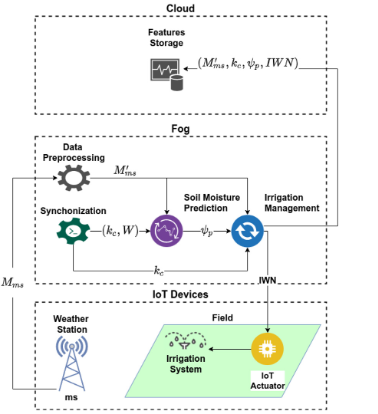

*Decision-support services distributed across cloud, fog, and IoT layers.*

For deployment, the selected Keras model is converted to TensorFlow Lite. The exported model still requires the same imputer and scalers used during training.


In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(final_model)
tflite_model = converter.convert()

TFLITE_PATH = OUTPUT_DIR / f"{FINAL_MODEL_NAME}_{FINAL_TARGET}.tflite"
TFLITE_PATH.write_bytes(tflite_model)

print(f"Saved TensorFlow Lite model to: {TFLITE_PATH}")
print(f"Model size: {TFLITE_PATH.stat().st_size / 1024:.2f} KiB")

## Local inference benchmark

The following benchmark measures TensorFlow Lite inference latency. For a publication-grade fog evaluation, execute the benchmark on the target Raspberry Pi under controlled background load and also measure CPU, RAM, and energy consumption.


In [ ]:
# Lightweight local inference benchmark.
# For a publication-grade fog evaluation, run this cell on the target Raspberry Pi
# under controlled background load and repeat the experiment several times.

import time

interpreter = tf.lite.Interpreter(model_path=str(TFLITE_PATH))
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

sample_input = sample_model[:1].astype(input_details[0]["dtype"])

latencies_ms = []
for _ in range(100):
    started = time.perf_counter()
    interpreter.set_tensor(input_details[0]["index"], sample_input)
    interpreter.invoke()
    _ = interpreter.get_tensor(output_details[0]["index"])
    latencies_ms.append((time.perf_counter() - started) * 1_000)

latency_summary = pd.Series(latencies_ms).describe(
    percentiles=[0.50, 0.90, 0.95, 0.99]
)
display(latency_summary.to_frame("latency_ms"))

# Part VIII — Scientific Interpretation

The publication reports that prediction is generally more difficult at **15 cm** than at deeper layers. The superficial layer is more strongly affected by evaporation and short-term weather variability.

A model should not be selected from mean MAE alone. A responsible comparison should also consider:

- variability across folds;
- error by soil depth;
- physically implausible predictions;
- stability after inverse scaling;
- sensitivity to missing inputs;
- inference latency and memory on the fog node;
- consequences for downstream irrigation decisions.

The neural output is not itself the irrigation command. Predicted matric potential feeds the water-retention and irrigation-management logic.


## Limitations

- The original data are not distributed with this notebook.
- Exact replication depends on the original data, software versions, and model initialization.
- The dense baseline is a modern Keras approximation rather than a guaranteed reconstruction of every internal detail of the published GDR implementation.
- LSTM input organization should be revisited when explicit temporal windows are available.
- Domain thresholds should not be transferred to another crop, soil, or climate without expert review.
- The fog benchmark should be repeated on the actual target hardware.


## Reproducibility Improvements

This notebook avoids several common risks in exploratory workflows:

- no hard-coded Google Drive path;
- no dependency on an external helper notebook;
- no shared Keras model instance across folds or depths;
- no fitting of KNN imputation or scaling on the full dataset;
- no test-fold leakage;
- MAE calculated after inverse transformation to kPa;
- deterministic seeds centralized in one configuration;
- domain rules implemented as named functions;
- generated artifacts stored under `outputs/`.


## Citation

```bibtex
@article{cordeiro2022towards,
  title   = {Towards Smart Farming: Fog-enabled intelligent irrigation system using deep neural networks},
  author  = {Cordeiro, Matheus and Markert, Catherine and Araújo, Sayonara S. and Campos, Nídia G. S. and Gondim, Rubens S. and Coelho da Silva, Ticiana L. and da Rocha, Atslands R.},
  journal = {Future Generation Computer Systems},
  volume  = {129},
  pages   = {115--124},
  year    = {2022},
  doi     = {10.1016/j.future.2021.11.013}
}
```


## Suggested Next Experiments

1. Build explicit temporal windows instead of treating the feature vector as a pseudo-sequence.
2. Compare recurrent models with temporal convolutional networks and compact Transformers.
3. Add uncertainty intervals to matric-potential predictions.
4. Evaluate oversampling strategies for rare soil conditions.
5. Measure energy consumption in addition to CPU, RAM, and latency.
6. Investigate online or incremental adaptation at the fog layer.
7. Evaluate generalization across monitoring spots, crops, and seasons.
8. Add physically informed penalties based on soil-water constraints.
